In [1]:
!pip install kagglehub scikit-learn matplotlib seaborn pandas numpy

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, auc, classification_report
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
import os

path = kagglehub.dataset_download("data855/heart-disease")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files found:", files)

Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\data855\heart-disease\versions\1
Files found: ['heart.csv']


In [4]:
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
print('='*50)
print('DATASET INFORMATION')
print('='*50)
print(f'Shape: {df.shape}')
print(f'\nColumn Names: {list(df.columns)}')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()}')

# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'Filled missing values in: {col}')

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')

print(f'\n✅ Clean Dataset Shape: {df.shape}')
print(f'\nTarget Value Counts:\n{df["target"].value_counts()}')
df.describe().round(2)

DATASET INFORMATION
Shape: (303, 14)

Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Duplicates removed: 1

✅ Clean Dataset Shape: (302, 14)

Target Value Counts:
target
1    164
0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.42,0.68,0.96,131.60,246.50,0.15,0.53,149.57,0.33,1.04,1.40,0.72,2.31,0.54
std,9.05,0.47,1.03,17.56,51.75,0.36,0.53,22.90,0.47,1.16,0.62,1.01,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.50,1.00,1.00,130.00,240.50,0.00,1.00,152.50,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.75,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


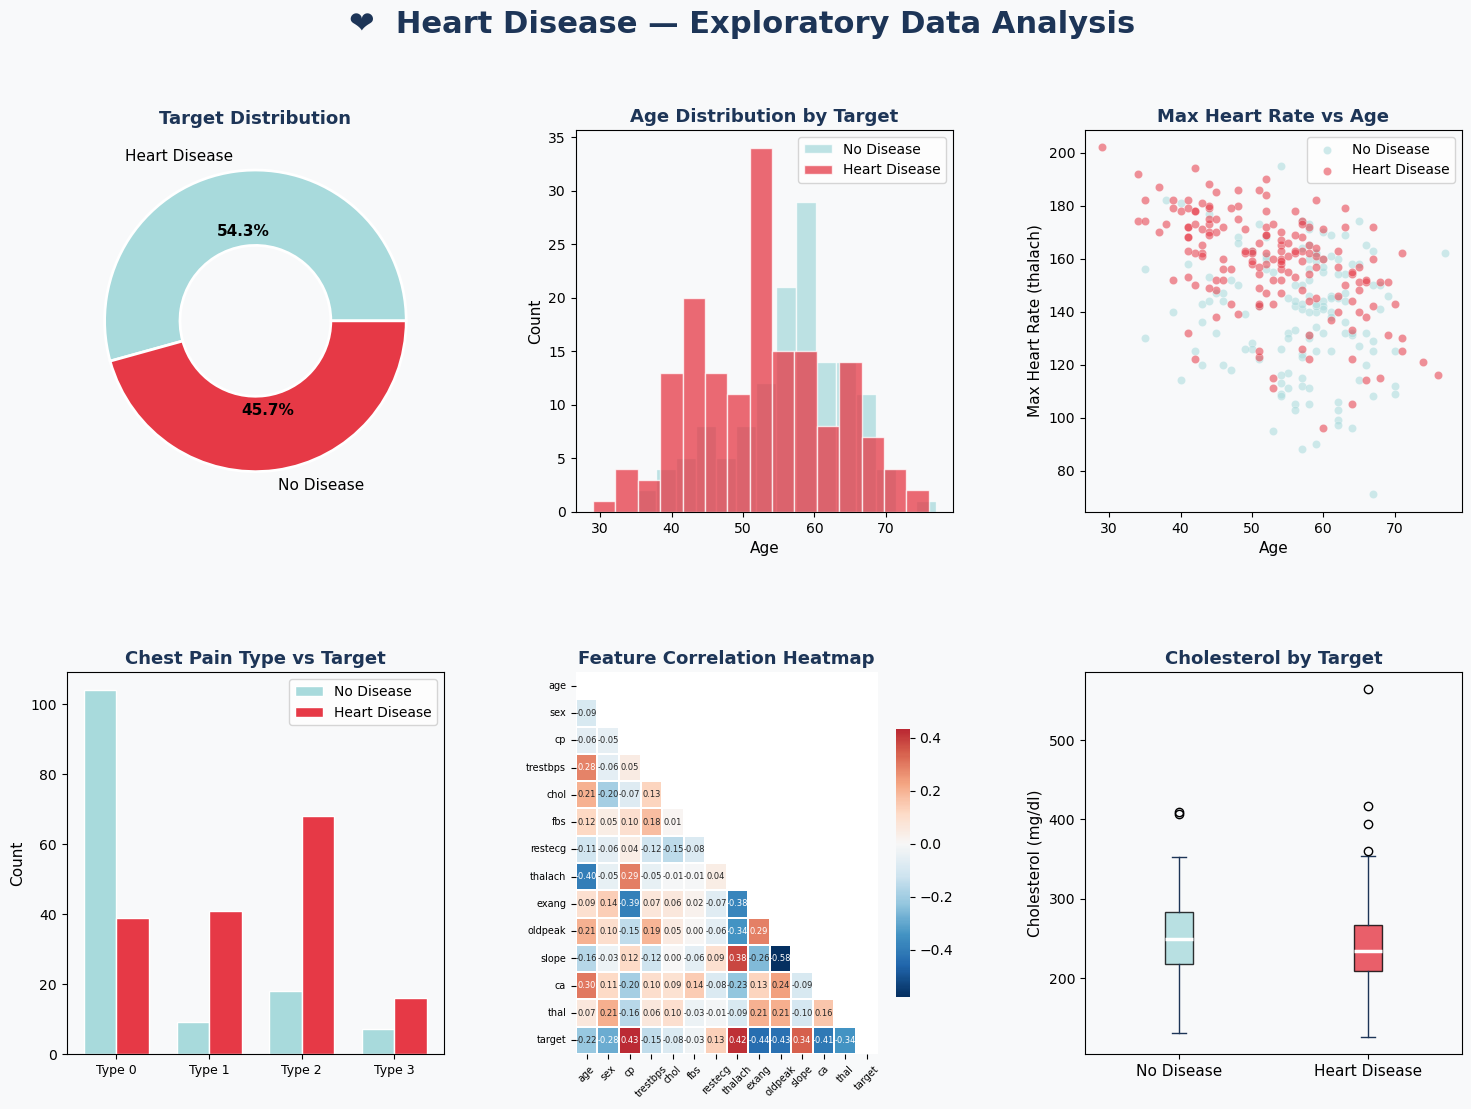

✅ EDA Complete


In [6]:
RED   = '#E63946'
BLUE  = '#1D3557'
LIGHT = '#A8DADC'
BG    = '#F8F9FA'
colors = [LIGHT, RED]
label_map = {0: 'No Disease', 1: 'Heart Disease'}

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('❤️  Heart Disease — Exploratory Data Analysis',
             fontsize=22, fontweight='bold', color=BLUE, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# Plot 1: Target Distribution (Donut)
ax0 = fig.add_subplot(gs[0, 0])
counts = df['target'].value_counts()
wedges, texts, autotexts = ax0.pie(
    counts, labels=[label_map[i] for i in counts.index],
    autopct='%1.1f%%', colors=colors,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11))
for at in autotexts: at.set_fontweight('bold')
ax0.set_title('Target Distribution', fontsize=13, fontweight='bold', color=BLUE)

# Plot 2: Age Distribution
ax1 = fig.add_subplot(gs[0, 1])
for t, c, lbl in zip([0,1], colors, label_map.values()):
    ax1.hist(df[df['target']==t]['age'], bins=15, alpha=0.75,
             color=c, label=lbl, edgecolor='white')
ax1.set_xlabel('Age', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Age Distribution by Target', fontsize=13, fontweight='bold', color=BLUE)
ax1.legend(); ax1.set_facecolor(BG)

# Plot 3: Max Heart Rate vs Age
ax2 = fig.add_subplot(gs[0, 2])
for t, c, lbl in zip([0,1], colors, label_map.values()):
    sub = df[df['target']==t]
    ax2.scatter(sub['age'], sub['thalach'], alpha=0.55, color=c,
                s=35, label=lbl, edgecolors='white', linewidth=0.3)
ax2.set_xlabel('Age', fontsize=11)
ax2.set_ylabel('Max Heart Rate (thalach)', fontsize=11)
ax2.set_title('Max Heart Rate vs Age', fontsize=13, fontweight='bold', color=BLUE)
ax2.legend(); ax2.set_facecolor(BG)

# Plot 4: Chest Pain Type
ax3 = fig.add_subplot(gs[1, 0])
cp_counts = df.groupby(['cp','target']).size().unstack(fill_value=0)
x = np.arange(len(cp_counts))
w = 0.35
ax3.bar(x - w/2, cp_counts.get(0, 0), w, color=LIGHT, label='No Disease', edgecolor='white')
ax3.bar(x + w/2, cp_counts.get(1, 0), w, color=RED, label='Heart Disease', edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Type {i}' for i in cp_counts.index], fontsize=9)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Chest Pain Type vs Target', fontsize=13, fontweight='bold', color=BLUE)
ax3.legend(); ax3.set_facecolor(BG)

# Plot 5: Correlation Heatmap
ax4 = fig.add_subplot(gs[1, 1])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax4, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.3, cbar_kws={'shrink': 0.7})
ax4.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', color=BLUE)
ax4.tick_params(axis='x', labelsize=7, rotation=45)
ax4.tick_params(axis='y', labelsize=7, rotation=0)

# Plot 6: Cholesterol Boxplot
ax5 = fig.add_subplot(gs[1, 2])
data_box = [df[df['target']==0]['chol'], df[df['target']==1]['chol']]
bp = ax5.boxplot(data_box, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(color=BLUE),
                 capprops=dict(color=BLUE))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax5.set_xticklabels(['No Disease', 'Heart Disease'], fontsize=11)
ax5.set_ylabel('Cholesterol (mg/dl)', fontsize=11)
ax5.set_title('Cholesterol by Target', fontsize=13, fontweight='bold', color=BLUE)
ax5.set_facecolor(BG)

plt.tight_layout()
plt.show()
print('✅ EDA Complete')

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print('✅ Data split & scaled')

Training samples : 241
Testing  samples : 61
✅ Data split & scaled


In [8]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print('✅ Both models trained!')
print(f'Logistic Regression Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'Decision Tree Accuracy       : {accuracy_score(y_test, dt_pred):.4f}')

✅ Both models trained!
Logistic Regression Accuracy : 0.7869
Decision Tree Accuracy       : 0.8197


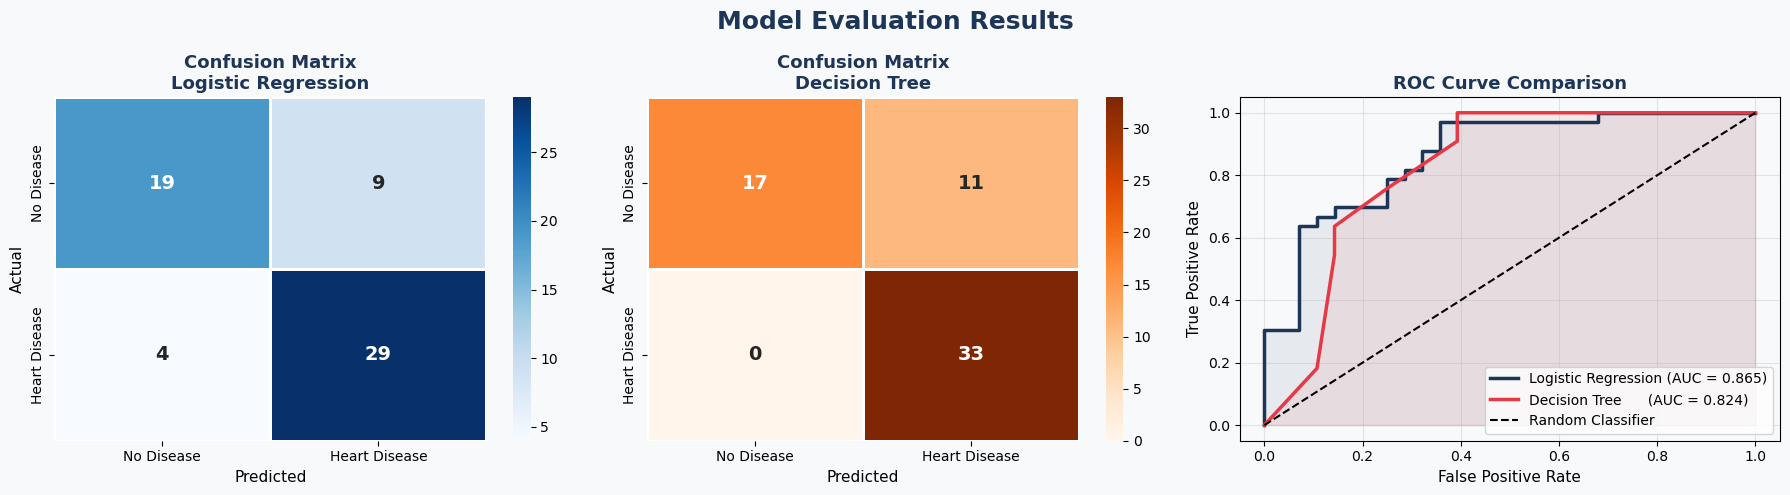

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Model Evaluation Results', fontsize=18, fontweight='bold', color=BLUE)

# Confusion Matrix: Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=1, linecolor='white',
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=13, fontweight='bold', color=BLUE)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Confusion Matrix: Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[1],
            cmap='Oranges', linewidths=1, linecolor='white',
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix\nDecision Tree', fontsize=13, fontweight='bold', color=BLUE)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

axes[2].plot(fpr_lr, tpr_lr, color=BLUE, lw=2.5,
             label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[2].plot(fpr_dt, tpr_dt, color=RED, lw=2.5,
             label=f'Decision Tree      (AUC = {auc_dt:.3f})')
axes[2].plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
axes[2].fill_between(fpr_lr, tpr_lr, alpha=0.08, color=BLUE)
axes[2].fill_between(fpr_dt, tpr_dt, alpha=0.08, color=RED)
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold', color=BLUE)
axes[2].legend(fontsize=10, loc='lower right')
axes[2].set_facecolor(BG)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print('='*55)
print('LOGISTIC REGRESSION — Classification Report')
print('='*55)
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Heart Disease']))

print('='*55)
print('DECISION TREE — Classification Report')
print('='*55)
print(classification_report(y_test, dt_pred,
      target_names=['No Disease', 'Heart Disease']))

summary = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [f'{accuracy_score(y_test, lr_pred):.4f}',
                 f'{accuracy_score(y_test, dt_pred):.4f}'],
    'ROC-AUC' : [f'{auc_lr:.4f}', f'{auc_dt:.4f}']
})
print('\n── Model Comparison Summary ──')
display(summary)

LOGISTIC REGRESSION — Classification Report
               precision    recall  f1-score   support

   No Disease       0.83      0.68      0.75        28
Heart Disease       0.76      0.88      0.82        33

     accuracy                           0.79        61
    macro avg       0.79      0.78      0.78        61
 weighted avg       0.79      0.79      0.78        61

DECISION TREE — Classification Report
               precision    recall  f1-score   support

   No Disease       1.00      0.61      0.76        28
Heart Disease       0.75      1.00      0.86        33

     accuracy                           0.82        61
    macro avg       0.88      0.80      0.81        61
 weighted avg       0.86      0.82      0.81        61


── Model Comparison Summary ──


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.7869,0.8647
1,Decision Tree,0.8197,0.8236


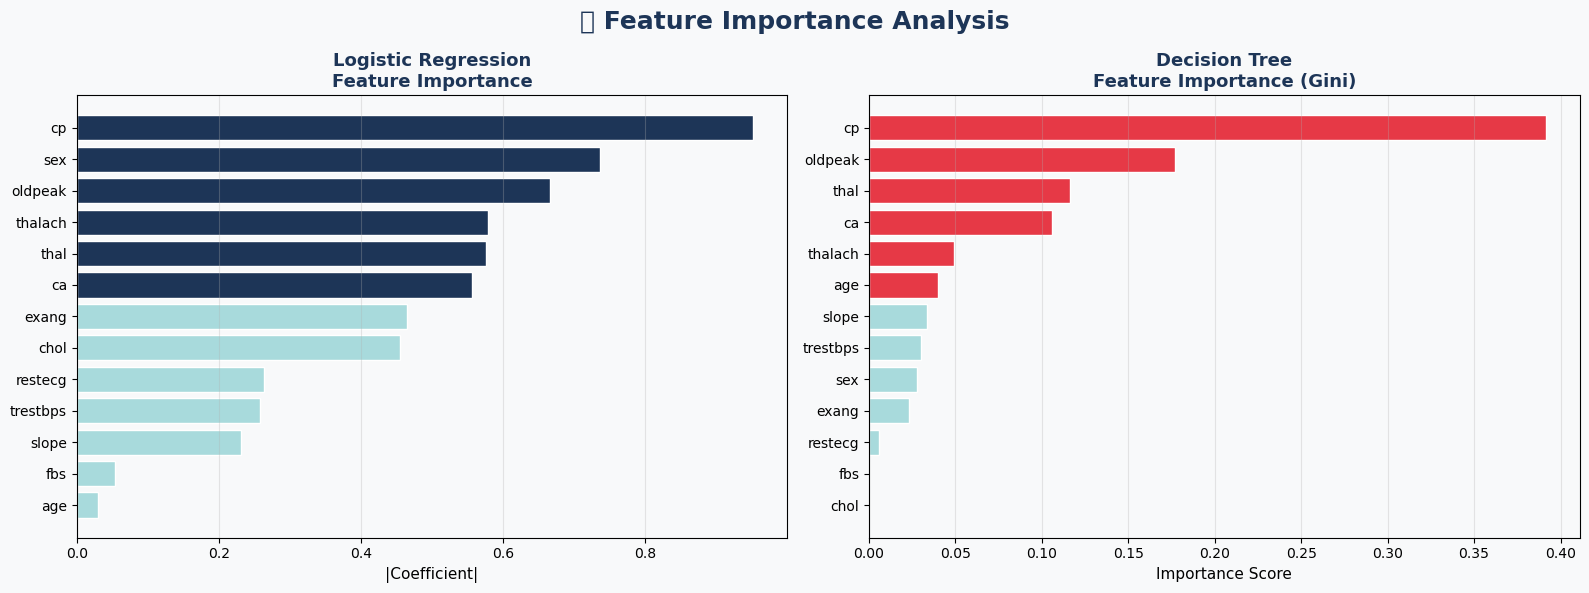

In [11]:
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('🔍 Feature Importance Analysis',
             fontsize=18, fontweight='bold', color=BLUE)

# Logistic Regression Coefficients
lr_coefs  = np.abs(lr.coef_[0])
lr_sorted = np.argsort(lr_coefs)
axes[0].barh([feature_names[i] for i in lr_sorted],
             lr_coefs[lr_sorted],
             color=[BLUE if v > np.median(lr_coefs) else LIGHT
                    for v in lr_coefs[lr_sorted]],
             edgecolor='white')
axes[0].set_xlabel('|Coefficient|', fontsize=11)
axes[0].set_title('Logistic Regression\nFeature Importance',
                  fontsize=13, fontweight='bold', color=BLUE)
axes[0].set_facecolor(BG)
axes[0].grid(axis='x', alpha=0.3)

# Decision Tree Feature Importances
dt_imp    = dt.feature_importances_
dt_sorted = np.argsort(dt_imp)
axes[1].barh([feature_names[i] for i in dt_sorted],
             dt_imp[dt_sorted],
             color=[RED if v > np.median(dt_imp) else LIGHT
                    for v in dt_imp[dt_sorted]],
             edgecolor='white')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Decision Tree\nFeature Importance (Gini)',
                  fontsize=13, fontweight='bold', color=BLUE)
axes[1].set_facecolor(BG)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
fi_df = pd.DataFrame({
    'Feature'            : feature_names,
    'LR_Coefficient_Abs' : np.abs(lr.coef_[0]).round(4),
    'DT_Importance'      : dt.feature_importances_.round(4)
}).sort_values('DT_Importance', ascending=False)

print('='*55)
print('    HEART DISEASE PREDICTION — FINAL SUMMARY')
print('='*55)
print(f'Dataset Shape        : {df.shape}')
print(f'Features Used        : {X.shape[1]}')
print(f'Train/Test Split     : 80% / 20%')
print()
print(f'Logistic Regression:')
print(f'  Accuracy           : {accuracy_score(y_test, lr_pred):.4f}')
print(f'  ROC-AUC            : {auc_lr:.4f}')
print()
print(f'Decision Tree:')
print(f'  Accuracy           : {accuracy_score(y_test, dt_pred):.4f}')
print(f'  ROC-AUC            : {auc_dt:.4f}')
print()
print(f'Top 3 Features       : {fi_df.head(3)["Feature"].tolist()}')
print('='*55)
print('✅ task Complete!')

display(fi_df)

    HEART DISEASE PREDICTION — FINAL SUMMARY
Dataset Shape        : (302, 14)
Features Used        : 13
Train/Test Split     : 80% / 20%

Logistic Regression:
  Accuracy           : 0.7869
  ROC-AUC            : 0.8647

Decision Tree:
  Accuracy           : 0.8197
  ROC-AUC            : 0.8236

Top 3 Features       : ['cp', 'oldpeak', 'thal']
✅ Project Complete!


,Feature,LR_Coefficient_Abs,DT_Importance
2,cp,0.9523,0.3915
9,oldpeak,0.6664,0.1769
12,thal,0.5763,0.1161
11,ca,0.5567,0.1061
7,thalach,0.5791,0.0493
0,age,0.0304,0.0398
10,slope,0.2309,0.0338
3,trestbps,0.2582,0.0301
1,sex,0.7366,0.0278
8,exang,0.4644,0.0231
